In [43]:
import random 
import requests 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [44]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [45]:
urls = {
    "train": "https://huggingface.co/datasets/AutonLab/Timeseries-PILE/resolve/main/classification/UCR/ECG5000/ECG5000_TRAIN.ts?download=true",
    "test": "https://huggingface.co/datasets/AutonLab/Timeseries-PILE/resolve/main/classification/UCR/ECG5000/ECG5000_TEST.ts?download=true",
}


In [46]:
def load_ecg5000_ts(urls):
    rows = []
    for split, url in urls.items():
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        for line in response.text.splitlines():
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("@"):
                continue

            values, label = line.rsplit(":", 1)
            rows.append([float(label), *map(float, values.split(","))])

    return pd.DataFrame(rows)


df = load_ecg5000_ts(urls)

labels = df.iloc[:, 0].values
signals = df.iloc[:, 1:].values.astype(np.float32)

print("Signals shape:", signals.shape)
print("Labels shape:", labels.shape)

Signals shape: (5000, 140)
Labels shape: (5000,)


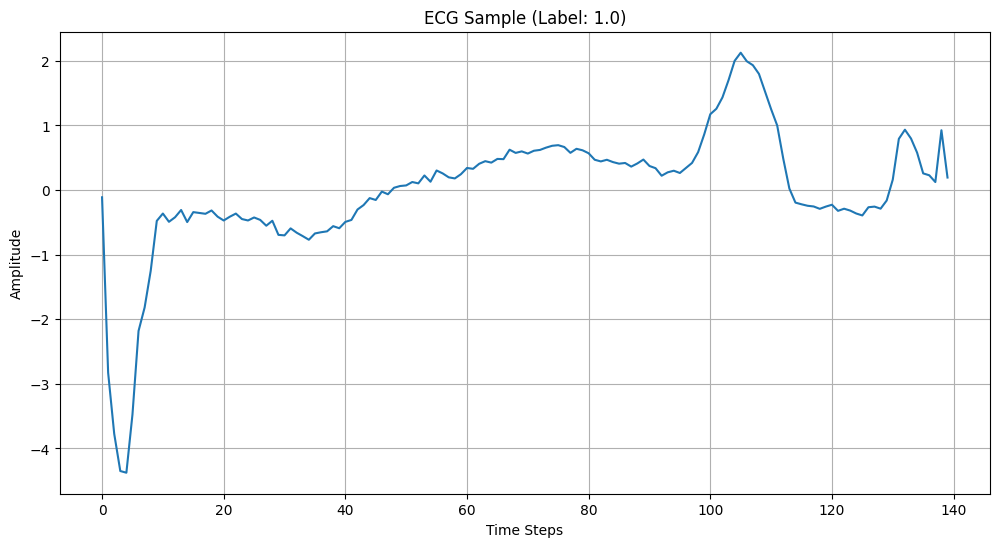

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(signals[0])
plt.title(f"ECG Sample (Label: {labels[0]})")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [48]:
scaler=StandardScaler()
signals_scaled=scaler.fit_transform(signals)
print("Scaled signals shape:", signals_scaled.shape)

Scaled signals shape: (5000, 140)


In [49]:
def make_prediction_dataset(signals, window_size=20):
    X,y=[],[]
    
    for signal in signals:
        for i in range(len(signal)-window_size):
            X.append(signal[i:i+window_size])
            y.append(signal[i+window_size])
            
    X=np.array(X,dtype=np.float32)
    y=np.array(y,dtype=np.float32)
    
    X=X[..., np.newaxis]  # Add channel dimension for LSTM
    y=y[..., np.newaxis]  # Add channel dimension for LSTM
    
    
    return X, y

X,y = make_prediction_dataset(signals_scaled, window_size=20)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600000, 20, 1)
y shape: (600000, 1)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

class ECGPredictionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        target = torch.tensor(self.y[idx], dtype=torch.float32).reshape(1)
        return x, target


train_ds = ECGPredictionDataset(X_train, y_train)
test_ds = ECGPredictionDataset(X_test, y_test)

MAX_TRAIN_SAMPLES = 20000
MAX_VAL_SAMPLES = 5000
BATCH_SIZE = 512

train_subset = Subset(train_ds, range(min(MAX_TRAIN_SAMPLES, len(train_ds))))
val_subset = Subset(test_ds, range(min(MAX_VAL_SAMPLES, len(test_ds))))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples used:", len(train_subset))
print("Val samples used:", len(val_subset))


Train samples used: 20000
Val samples used: 5000


In [51]:
class EEG_LSTM(nn.Module):
    def __init__(self,input_size=1,hidden_size=64,num_layers=1,dropout=0.0):
        super().__init__()
        real_dropout=dropout if num_layers>1 else 0.0
        self.lstm=nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=real_dropout)
        self.fc=nn.Linear(hidden_size,1)
        
    def forward(self,x):
        lstm_out,_=self.lstm(x)
        last_output=lstm_out[:,-1,:]
        out=self.fc(last_output)
        return out

In [52]:
hidden_space=[32,64,128]

layer_size= [1,2]
dropout_rates=[0.0,0.2,0.4]

actions=[
    "increase_hidden",
    "decrease_hidden",
    "increase_layers",
    "decrease_layers",
    "increase_dropout",
    "decrease_dropout",
    "keep"
]
states = [
    (h,l,d)
    for h in hidden_space
    for l in layer_size
    for d in dropout_rates
]

state transition function 

In [53]:
def next_state(state,action):
    h,l,d=state
    
    hi=hidden_space.index(h)
    li=layer_size.index(l)
    di=dropout_rates.index(d)
    
    
    if action == "increase_hidden":
        hi=min(hi+1,len(hidden_space)-1)
    elif action == "decrease_hidden":
        hi=max(hi-1,0)
    elif action == "increase_layers":
        li=min(li+1,len(layer_size)-1)
    elif action == "decrease_layers":
        li=max(li-1,0)
    elif action == "increase_dropout":
        di=min(di+1,len(dropout_rates)-1)
    elif action == "decrease_dropout":
        di=max(di-1,0)
        
    return (hidden_space[hi],layer_size[li],dropout_rates[di])
        

Q learning agent 

In [54]:
class QLearningOptimizer:
    def __init__(self,alpha=0.4,gamma=0.8,epsilon=0.5,**kwargs):
        if "epislon" in kwargs:
            epsilon=kwargs.pop("epislon")
        if kwargs:
            raise TypeError(f"Unexpected keyword argument(s): {', '.join(kwargs)}")
        self.alpha=alpha
        self.gamma=gamma
        self.epsilon=epsilon
        self.q_table={state:{action:0.0 for action in actions} for state in states}
    def choose_action(self,state):
        if random.random() < self.epsilon:
            return random.choice(actions)
        return max(self.q_table[state], key=self.q_table[state].get)
    def update(self,state,action,reward,new_state):
        curernt_q=self.q_table[state][action]
        max_future_q=max(self.q_table[new_state].values())
        td_error=reward + self.gamma*max_future_q - curernt_q
        self.q_table[state][action] += self.alpha*td_error
        return td_error
    
    def best_state(self):
        best_s=None 
        best_q=-np.inf
        for s in states:
            max_q=max(self.q_table[s].values())
            if max_q > best_q:
                best_q=max_q
                best_s=s
        return best_s
    
    

train one lstm config 

In [55]:
import math

TRAIN_ONE_CONFIG_VERSION = "manual_sgd_no_dynamo_no_numpy_v1"
print("Loaded train_one_config:", TRAIN_ONE_CONFIG_VERSION)

def regression_metrics(targets, preds):
    n = len(targets)
    if n == 0:
        raise ValueError("No validation predictions were collected")

    errors = [target - pred for target, pred in zip(targets, preds)]
    mse = sum(err * err for err in errors) / n
    rmse = math.sqrt(mse)
    mae = sum(abs(err) for err in errors) / n

    target_mean = sum(targets) / n
    ss_res = sum(err * err for err in errors)
    ss_tot = sum((target - target_mean) ** 2 for target in targets)
    r2 = 0.0 if ss_tot == 0 else 1.0 - (ss_res / ss_tot)

    return mse, rmse, mae, r2

def normalize_batch(xb, yb):
    if xb.dim() == 2:
        xb = xb.unsqueeze(-1)
    elif xb.dim() == 4 and xb.shape[-1] == 1:
        xb = xb.squeeze(-1)

    if yb.dim() == 1:
        yb = yb.unsqueeze(-1)

    return xb, yb

def manual_sgd_step(model, lr):
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is not None:
                param.add_(param.grad, alpha=-lr)


def train_one_config(state, train_loader, val_loader, epochs=3, lr=1e-3):
    hidden_size, num_layers, dropout = state

    model = EEG_LSTM(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            xb, yb = normalize_batch(xb, yb)

            pred = model(xb)
            loss = criterion(pred, yb)

            model.zero_grad(set_to_none=True)
            loss.backward()
            manual_sgd_step(model, lr)

    model.eval()

    val_losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            xb, yb = normalize_batch(xb, yb)

            pred = model(xb)
            loss = criterion(pred, yb)

            val_losses.append(float(loss.item()))
            all_preds.extend(pred.detach().cpu().reshape(-1).tolist())
            all_targets.extend(yb.detach().cpu().reshape(-1).tolist())

    val_loss = sum(val_losses) / len(val_losses)
    mse, rmse, mae, r2 = regression_metrics(all_targets, all_preds)
    reward = -mse

    return reward, val_loss, mse, rmse, mae, r2


Loaded train_one_config: manual_sgd_no_dynamo_no_numpy_v1


updated

In [56]:
agent = QLearningOptimizer(
    alpha=0.4,
    gamma=0.8,
    epsilon=0.5
)

current_state = (64, 1, 0.0)

logs = []

if "train_loader" not in globals() or "val_loader" not in globals():
    BATCH_SIZE = globals().get("BATCH_SIZE", 512)
    MAX_TRAIN_SAMPLES = globals().get("MAX_TRAIN_SAMPLES", 20000)
    MAX_VAL_SAMPLES = globals().get("MAX_VAL_SAMPLES", 5000)
    train_subset = Subset(train_ds, range(min(MAX_TRAIN_SAMPLES, len(train_ds))))
    val_subset = Subset(test_ds, range(min(MAX_VAL_SAMPLES, len(test_ds))))
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

EPISODES = 12

for episode in range(EPISODES):
    action = agent.choose_action(current_state)

    new_state = next_state(current_state, action)

    reward, val_loss, mse, rmse, mae, r2 = train_one_config(
        state=new_state,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=3
    )

    td_error = agent.update(
        state=current_state,
        action=action,
        reward=reward,
        new_state=new_state
    )

    logs.append({
        "episode": episode + 1,
        "state": current_state,
        "action": action,
        "new_state": new_state,
        "val_loss": val_loss,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "reward": reward,
        "td_error": td_error
    })

    print(
        f"Episode {episode+1:02d} | "
        f"State={current_state} | "
        f"Action={action} | "
        f"Next={new_state} | "
        f"MSE={mse:.6f} | "
        f"RMSE={rmse:.6f} | "
        f"MAE={mae:.6f} | "
        f"R2={r2:.4f} | "
        f"Reward={reward:.6f} | "
        f"TD Error={td_error:.6f}"
    )

    current_state = new_state


Episode 01 | State=(64, 1, 0.0) | Action=increase_dropout | Next=(64, 1, 0.2) | MSE=0.977072 | RMSE=0.988470 | MAE=0.741740 | R2=0.0430 | Reward=-0.977072 | TD Error=-0.977072
Episode 02 | State=(64, 1, 0.2) | Action=decrease_hidden | Next=(32, 1, 0.2) | MSE=1.053736 | RMSE=1.026517 | MAE=0.771081 | R2=-0.0321 | Reward=-1.053736 | TD Error=-1.053736
Episode 03 | State=(32, 1, 0.2) | Action=increase_hidden | Next=(64, 1, 0.2) | MSE=1.028619 | RMSE=1.014209 | MAE=0.759966 | R2=-0.0075 | Reward=-1.028619 | TD Error=-1.028619
Episode 04 | State=(64, 1, 0.2) | Action=increase_hidden | Next=(128, 1, 0.2) | MSE=0.986922 | RMSE=0.993439 | MAE=0.745224 | R2=0.0334 | Reward=-0.986922 | TD Error=-0.986922
Episode 05 | State=(128, 1, 0.2) | Action=keep | Next=(128, 1, 0.2) | MSE=0.969585 | RMSE=0.984675 | MAE=0.738607 | R2=0.0504 | Reward=-0.969585 | TD Error=-0.969585
Episode 06 | State=(128, 1, 0.2) | Action=increase_hidden | Next=(128, 1, 0.2) | MSE=0.943495 | RMSE=0.971337 | MAE=0.727927 | R2=

In [57]:
results_df = pd.DataFrame(logs)

results_df[
    [
        "episode",
        "state",
        "action",
        "new_state",
        "mse",
        "rmse",
        "mae",
        "r2",
        "reward",
        "td_error"
    ]
]

,episode,state,action,new_state,mse,rmse,mae,r2,reward,td_error
0,1,"(64, 1, 0.0)",increase_dropout,"(64, 1, 0.2)",0.977072,0.988470,0.741740,0.043023,-0.977072,-0.977072
1,2,"(64, 1, 0.2)",decrease_hidden,"(32, 1, 0.2)",1.053736,1.026517,0.771081,-0.032064,-1.053736,-1.053736
2,3,"(32, 1, 0.2)",increase_hidden,"(64, 1, 0.2)",1.028619,1.014209,0.759966,-0.007463,-1.028619,-1.028619
3,4,"(64, 1, 0.2)",increase_hidden,"(128, 1, 0.2)",0.986922,0.993439,0.745224,0.033376,-0.986922,-0.986922
4,5,"(128, 1, 0.2)",keep,"(128, 1, 0.2)",0.969585,0.984675,0.738607,0.050356,-0.969585,-0.969585
5,6,"(128, 1, 0.2)",increase_hidden,"(128, 1, 0.2)",0.943495,0.971337,0.727927,0.075909,-0.943495,-0.943495
6,7,"(128, 1, 0.2)",decrease_hidden,"(64, 1, 0.2)",0.966043,0.982875,0.735379,0.053826,-0.966043,-0.966043
7,8,"(64, 1, 0.2)",increase_layers,"(64, 2, 0.2)",1.007237,1.003612,0.753646,0.013479,-1.007237,-1.007237
8,9,"(64, 2, 0.2)",increase_dropout,"(64, 2, 0.4)",1.015997,1.007967,0.758173,0.004899,-1.015997,-1.015997
9,10,"(64, 2, 0.4)",keep,"(64, 2, 0.4)",1.012286,1.006124,0.756393,0.008533,-1.012286,-1.012286


In [58]:
best_row = results_df.loc[results_df["mse"].idxmin()]

best_state = best_row["new_state"]

print("Best LSTM Configuration Found:")
print("Best State:", best_state)
print("Hidden Size:", best_state[0])
print("Num Layers:", best_state[1])
print("Dropout:", best_state[2])

print("\nBest Metrics:")
print("MSE:", best_row["mse"])
print("RMSE:", best_row["rmse"])
print("MAE:", best_row["mae"])
print("R2:", best_row["r2"])

Best LSTM Configuration Found:
Best State: (128, 1, 0.2)
Hidden Size: 128
Num Layers: 1
Dropout: 0.2

Best Metrics:
MSE: 0.9434952302117801
RMSE: 0.9713368263438693
MAE: 0.7279268967816955
R2: 0.07590949516548073


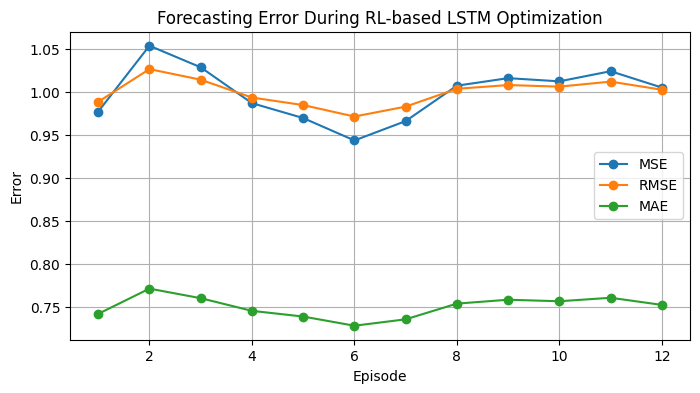

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["episode"], results_df["mse"], marker="o", label="MSE")
plt.plot(results_df["episode"], results_df["rmse"], marker="o", label="RMSE")
plt.plot(results_df["episode"], results_df["mae"], marker="o", label="MAE")

plt.xlabel("Episode")
plt.ylabel("Error")
plt.title("Forecasting Error During RL-based LSTM Optimization")
plt.legend()
plt.grid(True)
plt.show()

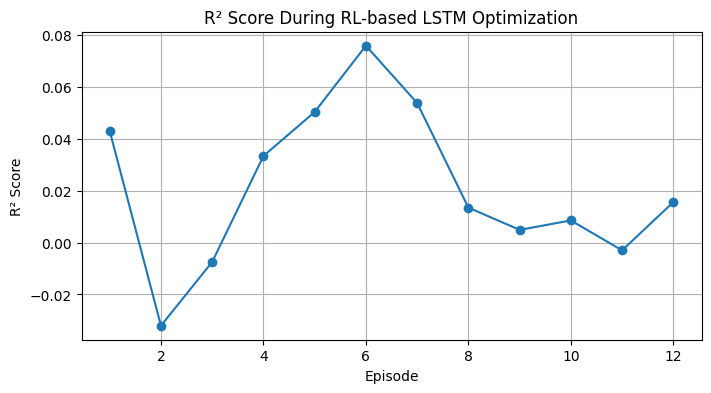

In [60]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["episode"], results_df["r2"], marker="o")

plt.xlabel("Episode")
plt.ylabel("R² Score")
plt.title("R² Score During RL-based LSTM Optimization")
plt.grid(True)
plt.show()

updated cell that will load same weight of same architecture 

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import copy

def train_one_config(
    state,
    train_loader,
    val_loader,
    previous_model=None,
    epochs=3
):
    hidden_size, num_layers, dropout = state

    model = EEG_LSTM(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    if previous_model is not None:
        try:
            model.load_state_dict(previous_model.state_dict())
            print("Loaded previous weights")
        except RuntimeError:
            print("Architecture changed, training from scratch")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()

    val_losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = criterion(pred, yb)

            val_losses.append(loss.item())
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(yb.cpu().numpy().flatten())

    val_loss = float(np.mean(val_losses))

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)

    reward = -mse

    saved_model = copy.deepcopy(model).to(DEVICE)

    return reward, val_loss, mse, rmse, mae, r2, saved_model

In [65]:
agent = QLearningOptimizer(
    alpha=0.4,
    gamma=0.8,
    epsilon=0.5
)

current_state = (64, 1, 0.0)
previous_model = None

logs = []

EPISODES = 12

for episode in range(EPISODES):
    action = agent.choose_action(current_state)
    new_state = next_state(current_state, action)

    reward, val_loss, mse, rmse, mae, r2, trained_model = train_one_config(
        state=new_state,
        train_loader=train_loader,
        val_loader=val_loader,
        previous_model=previous_model,
        epochs=3
    )

    td_error = agent.update(
        state=current_state,
        action=action,
        reward=reward,
        new_state=new_state
    )

    logs.append({
        "episode": episode + 1,
        "state": current_state,
        "action": action,
        "new_state": new_state,
        "val_loss": val_loss,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "reward": reward,
        "td_error": td_error
    })

    print(
        f"Episode {episode+1:02d} | "
        f"State={current_state} | "
        f"Action={action} | "
        f"Next={new_state} | "
        f"MSE={mse:.6f} | "
        f"RMSE={rmse:.6f} | "
        f"MAE={mae:.6f} | "
        f"R2={r2:.4f} | "
        f"Reward={reward:.6f} | "
        f"TD Error={td_error:.6f}"
    )

    previous_model = trained_model
    current_state = new_state

Episode 01 | State=(64, 1, 0.0) | Action=decrease_hidden | Next=(32, 1, 0.0) | MSE=0.203070 | RMSE=0.450633 | MAE=0.271956 | R2=0.8011 | Reward=-0.203070 | TD Error=-0.203070
Architecture changed, training from scratch
Episode 02 | State=(32, 1, 0.0) | Action=increase_hidden | Next=(64, 1, 0.0) | MSE=0.146125 | RMSE=0.382263 | MAE=0.241944 | R2=0.8569 | Reward=-0.146125 | TD Error=-0.146125
Architecture changed, training from scratch
Episode 03 | State=(64, 1, 0.0) | Action=increase_hidden | Next=(128, 1, 0.0) | MSE=0.134992 | RMSE=0.367413 | MAE=0.247055 | R2=0.8678 | Reward=-0.134992 | TD Error=-0.134992
Loaded previous weights
Episode 04 | State=(128, 1, 0.0) | Action=increase_hidden | Next=(128, 1, 0.0) | MSE=0.099625 | RMSE=0.315634 | MAE=0.202077 | R2=0.9024 | Reward=-0.099625 | TD Error=-0.099625
Loaded previous weights
Episode 05 | State=(128, 1, 0.0) | Action=keep | Next=(128, 1, 0.0) | MSE=0.094181 | RMSE=0.306889 | MAE=0.200000 | R2=0.9078 | Reward=-0.094181 | TD Error=-0.09

In [67]:
results_df = pd.DataFrame(logs)

results_df

,episode,state,action,new_state,val_loss,mse,rmse,mae,r2,reward,td_error
0,1,"(64, 1, 0.0)",decrease_hidden,"(32, 1, 0.0)",0.204828,0.203070,0.450633,0.271956,0.801106,-0.203070,-0.203070
1,2,"(32, 1, 0.0)",increase_hidden,"(64, 1, 0.0)",0.146816,0.146125,0.382263,0.241944,0.856880,-0.146125,-0.146125
2,3,"(64, 1, 0.0)",increase_hidden,"(128, 1, 0.0)",0.135398,0.134992,0.367413,0.247055,0.867784,-0.134992,-0.134992
3,4,"(128, 1, 0.0)",increase_hidden,"(128, 1, 0.0)",0.099929,0.099625,0.315634,0.202077,0.902424,-0.099625,-0.099625
4,5,"(128, 1, 0.0)",keep,"(128, 1, 0.0)",0.094684,0.094181,0.306889,0.200000,0.907756,-0.094181,-0.094181
5,6,"(128, 1, 0.0)",keep,"(128, 1, 0.0)",0.089062,0.088472,0.297443,0.195127,0.913347,-0.088472,-0.050800
6,7,"(128, 1, 0.0)",decrease_hidden,"(64, 1, 0.0)",0.151417,0.150709,0.388212,0.246435,0.852391,-0.150709,-0.150709
7,8,"(64, 1, 0.0)",increase_layers,"(64, 2, 0.0)",0.128522,0.128084,0.357888,0.226655,0.874550,-0.128084,-0.128084
8,9,"(64, 2, 0.0)",decrease_layers,"(64, 1, 0.0)",0.100390,0.100396,0.316853,0.200226,0.901669,-0.100396,-0.100396
9,10,"(64, 1, 0.0)",decrease_layers,"(64, 1, 0.0)",0.094835,0.094838,0.307958,0.195504,0.907112,-0.094838,-0.094838


In [68]:
best_row = results_df.loc[
    results_df["mse"].idxmin()
]

best_state = best_row["new_state"]

print("=" * 50)
print("BEST CONFIGURATION")
print("=" * 50)

print("State:", best_state)

print("\nMetrics")

print("MSE :", best_row["mse"])
print("RMSE:", best_row["rmse"])
print("MAE :", best_row["mae"])
print("R2  :", best_row["r2"])

print("=" * 50)

BEST CONFIGURATION
State: (128, 1, 0.0)

Metrics
MSE : 0.08847246
RMSE: 0.2974432
MAE : 0.19512674
R2  : 0.9133471450135796


In [69]:
best_row = results_df.loc[
    results_df["mse"].idxmin()
]

best_state = best_row["new_state"]

print("=" * 50)
print("BEST CONFIGURATION")
print("=" * 50)

print("State:", best_state)

print("\nMetrics")

print("MSE :", best_row["mse"])
print("RMSE:", best_row["rmse"])
print("MAE :", best_row["mae"])
print("R2  :", best_row["r2"])

print("=" * 50)

BEST CONFIGURATION
State: (128, 1, 0.0)

Metrics
MSE : 0.08847246
RMSE: 0.2974432
MAE : 0.19512674
R2  : 0.9133471450135796


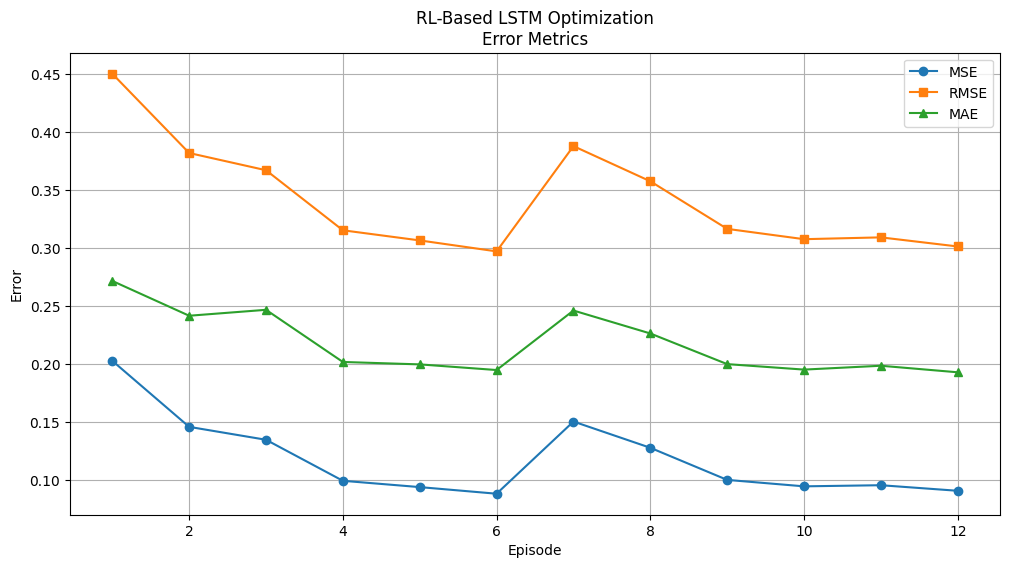

In [70]:
plt.figure(figsize=(12,6))

plt.plot(
    results_df["episode"],
    results_df["mse"],
    marker="o",
    label="MSE"
)

plt.plot(
    results_df["episode"],
    results_df["rmse"],
    marker="s",
    label="RMSE"
)

plt.plot(
    results_df["episode"],
    results_df["mae"],
    marker="^",
    label="MAE"
)

plt.xlabel("Episode")
plt.ylabel("Error")

plt.title(
    "RL-Based LSTM Optimization\nError Metrics"
)

plt.legend()
plt.grid(True)

plt.show()

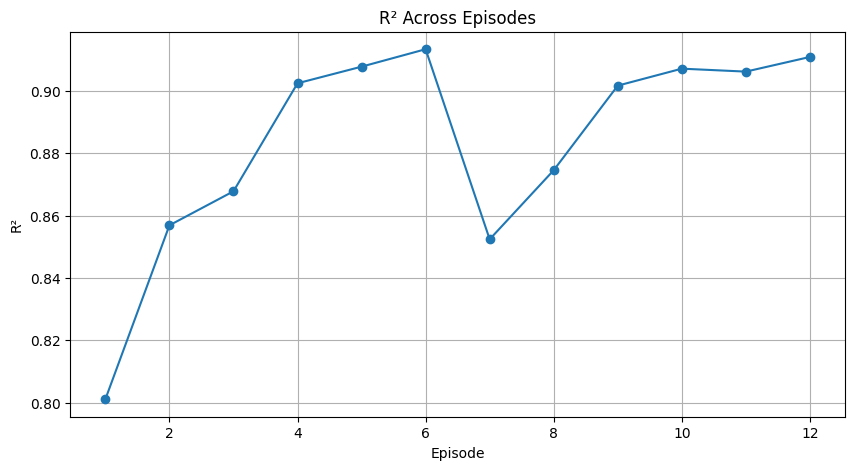

In [71]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["episode"],
    results_df["r2"],
    marker="o"
)

plt.xlabel("Episode")
plt.ylabel("R²")

plt.title(
    "R² Across Episodes"
)

plt.grid(True)

plt.show()

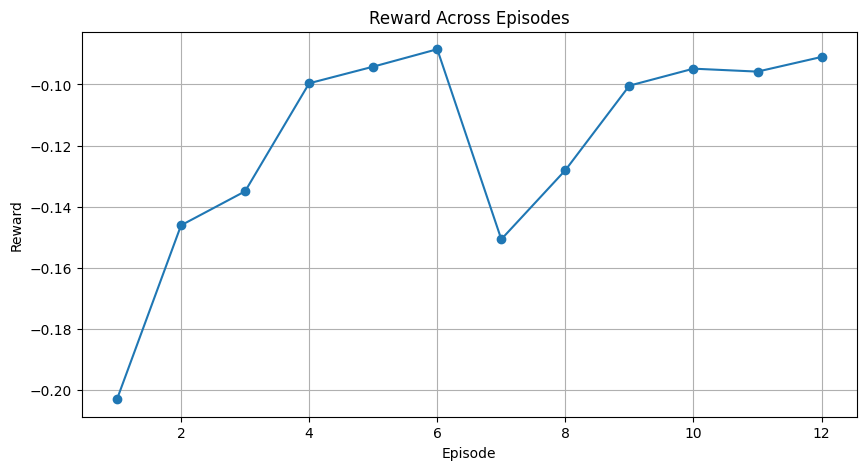

In [72]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["episode"],
    results_df["reward"],
    marker="o"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.title(
    "Reward Across Episodes"
)

plt.grid(True)

plt.show()

In [73]:
comparison_table = results_df[
    [
        "episode",
        "new_state",
        "mse",
        "rmse",
        "mae",
        "r2"
    ]
].copy()

comparison_table = comparison_table.sort_values(
    by="mse"
)

comparison_table.reset_index(
    drop=True,
    inplace=True
)

comparison_table

,episode,new_state,mse,rmse,mae,r2
0,6,"(128, 1, 0.0)",0.088472,0.297443,0.195127,0.913347
1,12,"(64, 1, 0.2)",0.091003,0.301667,0.193173,0.910868
2,5,"(128, 1, 0.0)",0.094181,0.306889,0.200000,0.907756
3,10,"(64, 1, 0.0)",0.094838,0.307958,0.195504,0.907112
4,11,"(64, 1, 0.0)",0.095804,0.309522,0.198827,0.906167
5,4,"(128, 1, 0.0)",0.099625,0.315634,0.202077,0.902424
6,9,"(64, 1, 0.0)",0.100396,0.316853,0.200226,0.901669
7,8,"(64, 2, 0.0)",0.128084,0.357888,0.226655,0.874550
8,3,"(128, 1, 0.0)",0.134992,0.367413,0.247055,0.867784
9,2,"(64, 1, 0.0)",0.146125,0.382263,0.241944,0.856880


In [74]:
best_hidden = best_state[0]
best_layers = best_state[1]
best_dropout = best_state[2]

print(best_hidden)
print(best_layers)
print(best_dropout)

128
1
0.0


In [76]:
final_model = EEG_LSTM(
    input_size=1,
    hidden_size=best_hidden,
    num_layers=best_layers,
    dropout=best_dropout
).to(DEVICE)

print(final_model)

EEG_LSTM(
  (lstm): LSTM(1, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
